In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from torch.utils.data import DataLoader, Dataset
from rdkit.Chem import AllChem

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import os

print(os.path.abspath(os.getcwd()))
# Load the enriched dataset (assumed to be in the same folder)
file_path = "/home/jovyan/Research Project/sdf_data/data.pkl"
df = pd.read_pickle(file_path)

# Ensure column name consistency
if "SMILES" in df.columns:
    smiles_column = "SMILES"
elif "smiles" in df.columns:
    smiles_column = "smiles"
else:
    raise ValueError("Dataset must contain a column named 'SMILES' or 'smiles'.")

# Define MolecularDataset class
class MolecularDataset(Dataset):
    def __init__(self, smiles_list):
        self.smiles = smiles_list
        self.fingerprints = [self.smiles_to_fp(smi) for smi in self.smiles]
    
    def smiles_to_fp(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024))
        else:
            return np.zeros(1024)  # Handle invalid molecules
    
    def __len__(self):
        return len(self.fingerprints)
    
    def __getitem__(self, idx):
        return torch.tensor(self.fingerprints[idx], dtype=torch.float32)

# Extract SMILES list from the dataset
smiles_list = df[smiles_column].dropna().tolist()  # Remove NaN values
dataset = MolecularDataset(smiles_list)

# Create DataLoader for training
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Display confirmation message
print(f"✅ Dataset successfully loaded with {len(dataset)} molecules for training.")


/home/jovyan/Research Project


[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerator
[18:53:47] DEPRECATION WARNING: please use MorganGenerat

✅ Dataset successfully loaded with 1158 molecules for training.


[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerator
[18:53:50] DEPRECATION WARNING: please use MorganGenerat

In [3]:
# --------------------
# 2️⃣ WGAN-GP Architecture
# --------------------
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)

In [4]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.model(x)

In [5]:
# Initialize models
generator = Generator(latent_dim=128, output_dim=1024)
discriminator = Discriminator(input_dim=1024)

def compute_gradient_penalty(D, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1)
    alpha = alpha.expand_as(real_samples)
    interpolates = alpha * real_samples + ((1 - alpha) * fake_samples)
    interpolates.requires_grad_(True)
    d_interpolates = D(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

Epoch 0, Loss D: 6.0461530685424805, Loss G: -1.599765658378601


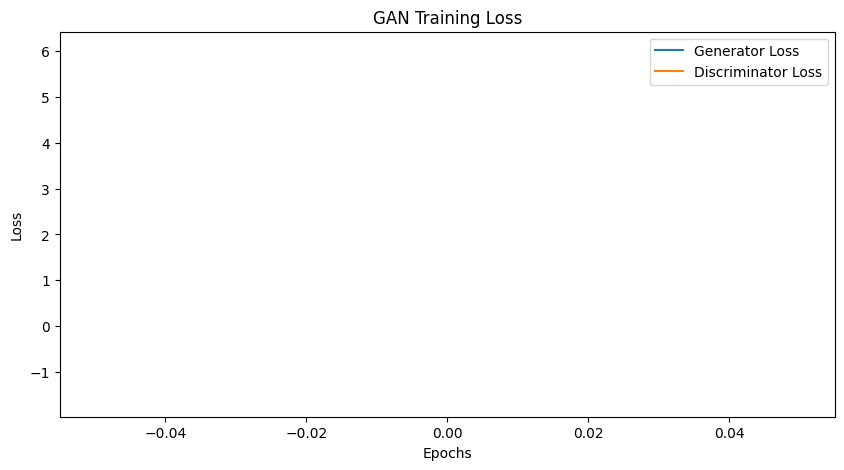

Epoch 500, Loss D: -2.046860694885254, Loss G: -0.6845214366912842


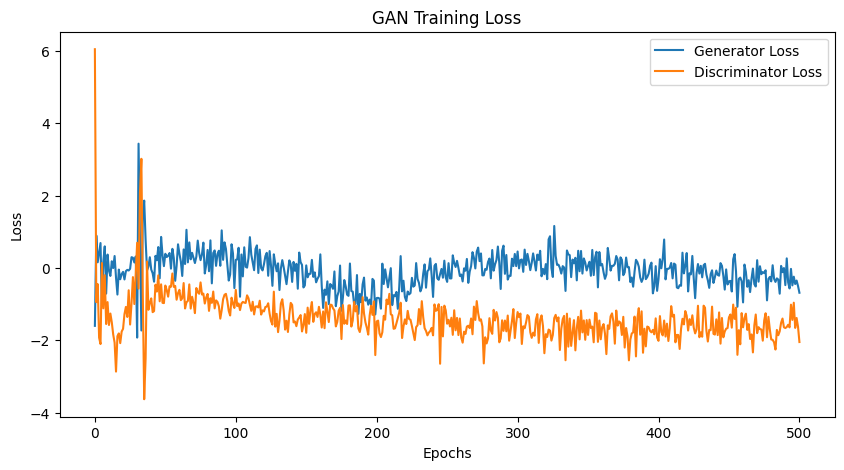

Epoch 1000, Loss D: -2.0330898761749268, Loss G: -0.7224090695381165


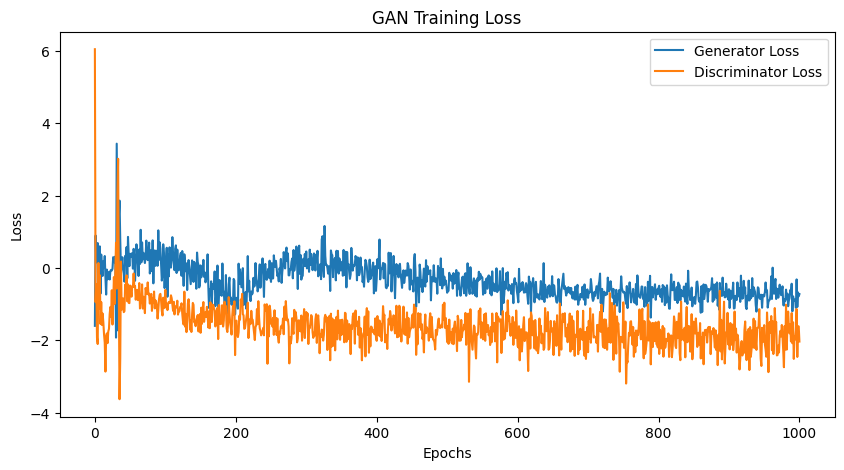

Epoch 1500, Loss D: -1.2469792366027832, Loss G: -0.9616246819496155


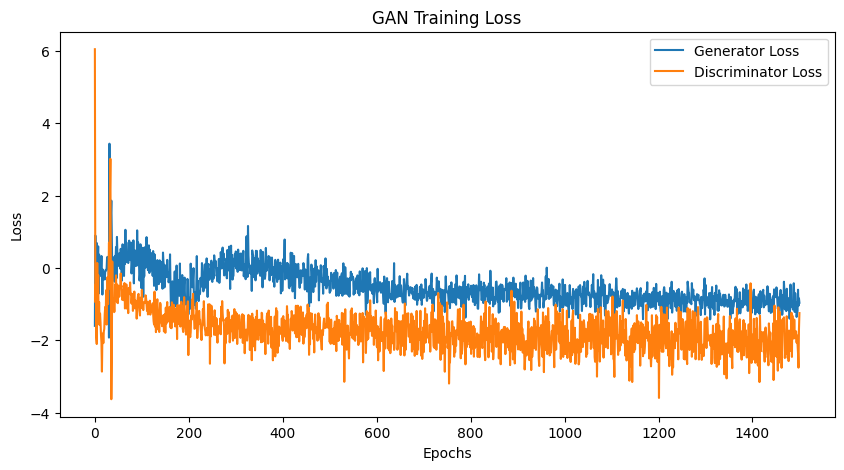

Epoch 2000, Loss D: -2.5822348594665527, Loss G: -1.6009019613265991


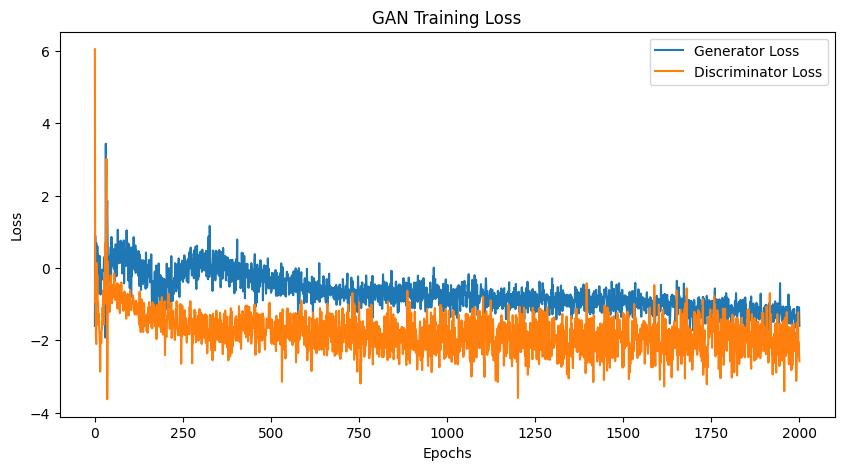

Epoch 2500, Loss D: -1.8635149002075195, Loss G: -1.7522822618484497


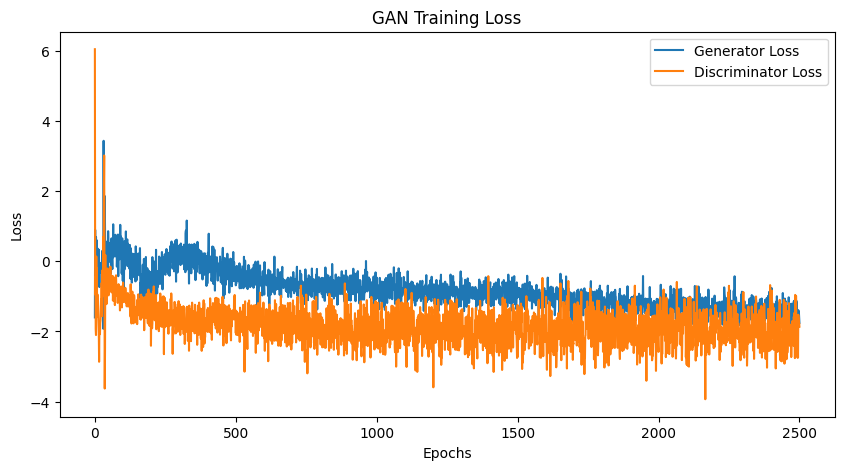

Epoch 3000, Loss D: -2.175274610519409, Loss G: -2.0397443771362305


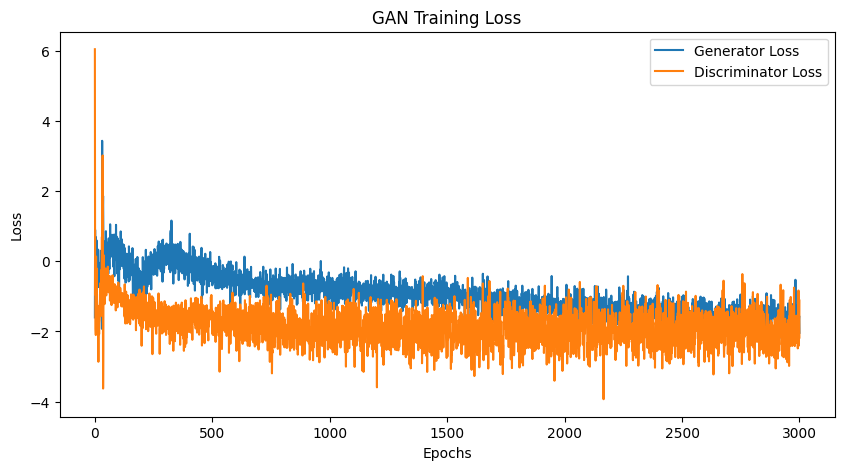

Epoch 3500, Loss D: -2.528925657272339, Loss G: -1.7943123579025269


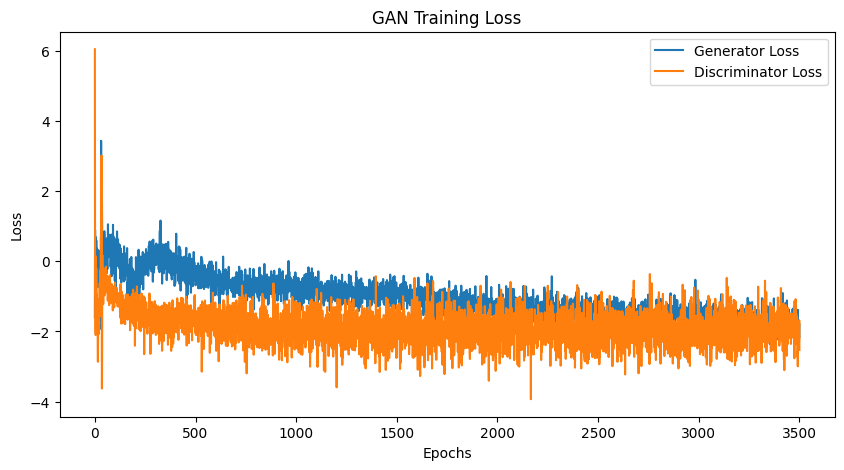

Epoch 4000, Loss D: -1.8314759731292725, Loss G: -1.5906257629394531


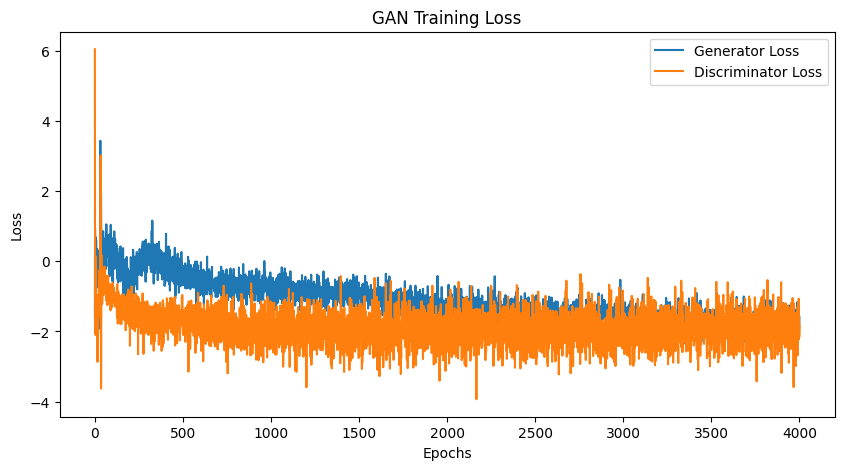

Epoch 4500, Loss D: -2.084036350250244, Loss G: -1.5302176475524902


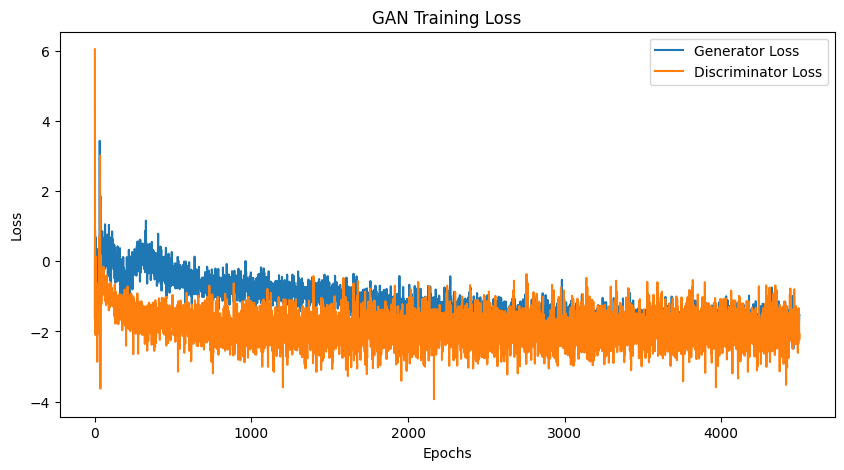

Epoch 5000, Loss D: -2.1778461933135986, Loss G: -1.3636823892593384


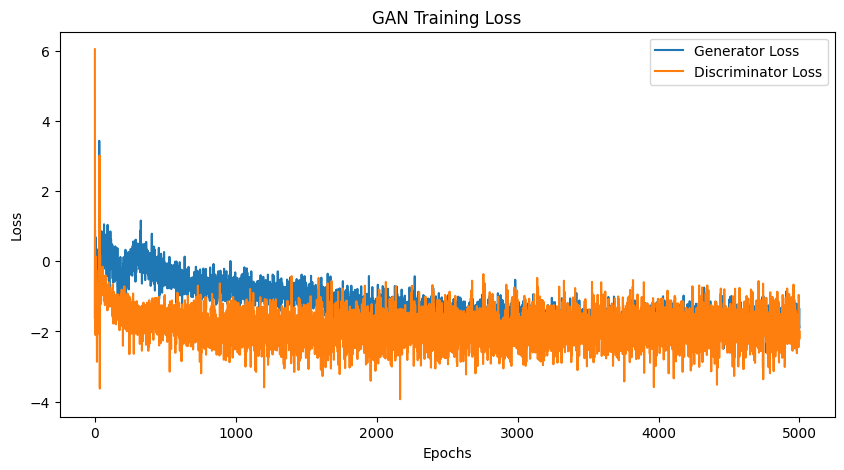

Epoch 5500, Loss D: -1.7659492492675781, Loss G: -1.623788833618164


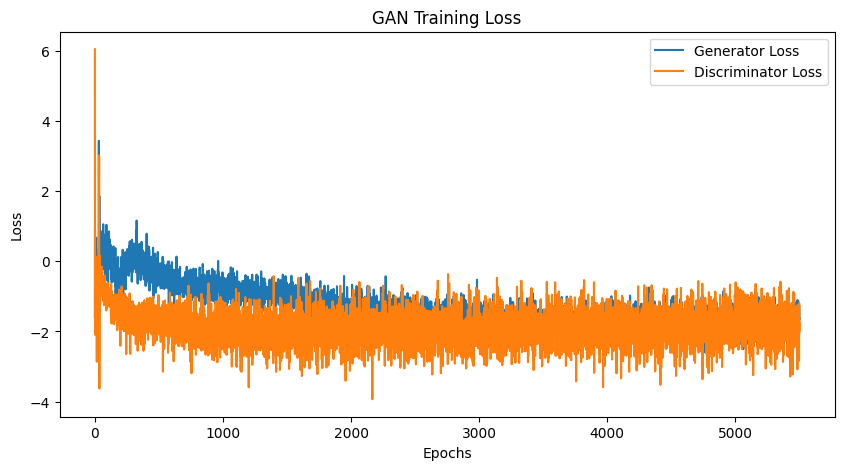

Epoch 6000, Loss D: -2.007716417312622, Loss G: -1.7118605375289917


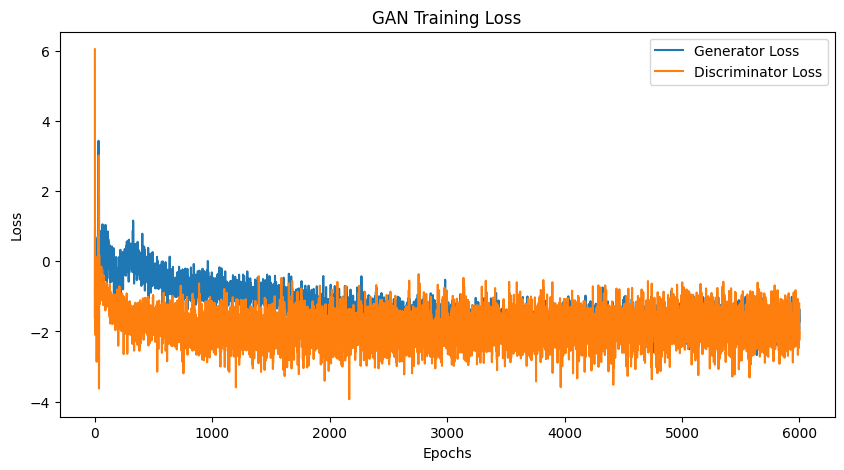

Epoch 6500, Loss D: -0.9516149759292603, Loss G: -1.922067642211914


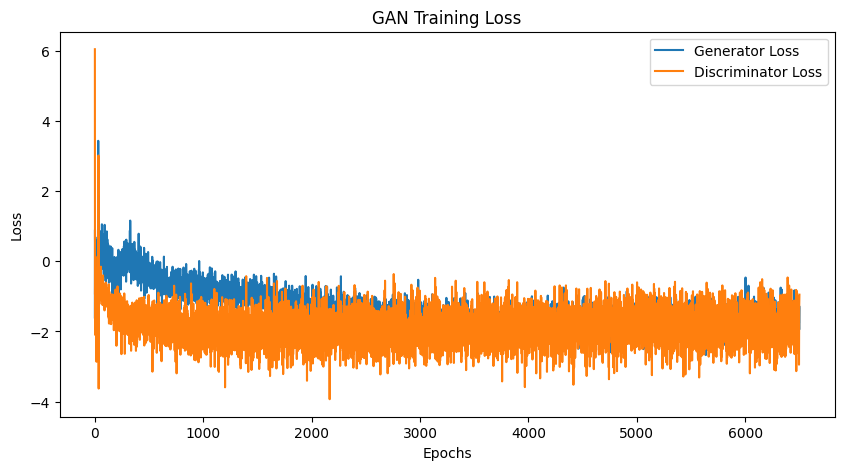

Epoch 7000, Loss D: -1.5226043462753296, Loss G: -1.2685222625732422


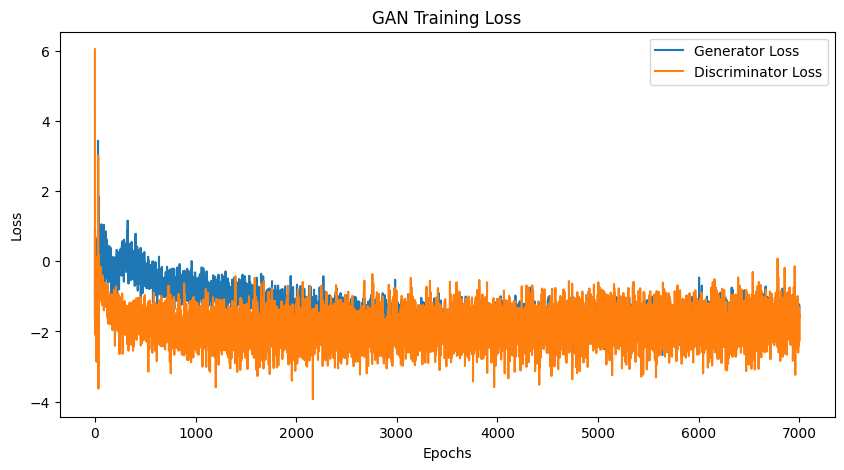

Epoch 7500, Loss D: -0.9763933420181274, Loss G: -1.254170298576355


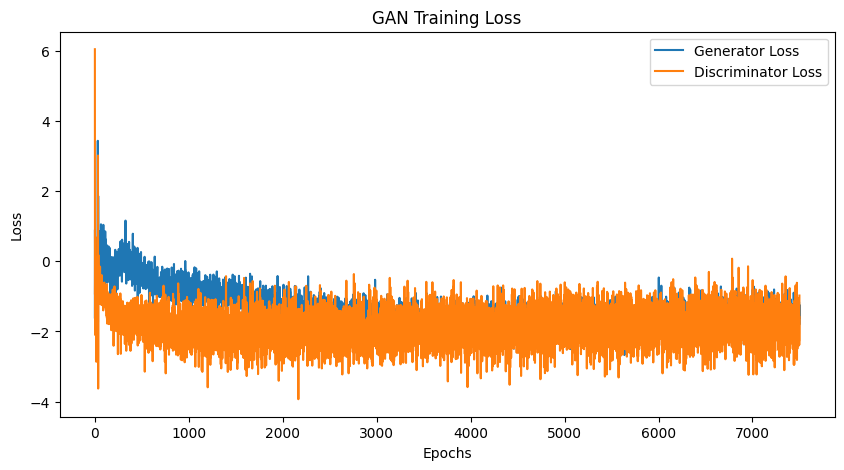

Epoch 8000, Loss D: -2.2097084522247314, Loss G: -1.4609426259994507


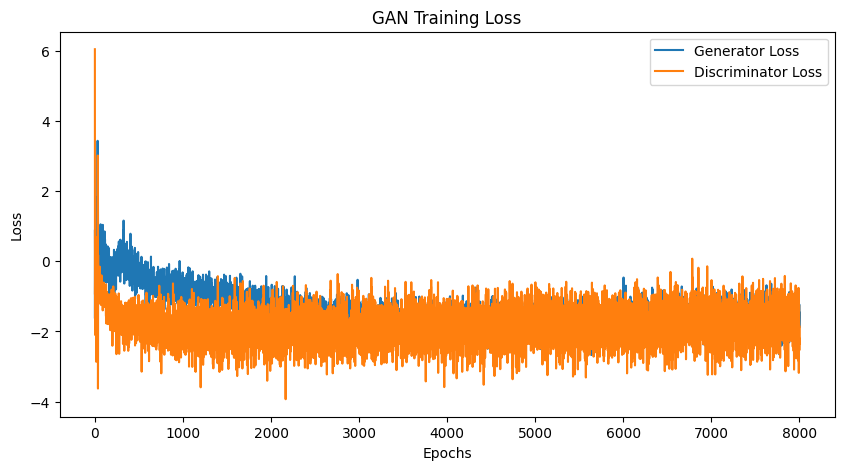

Epoch 8500, Loss D: -2.3152244091033936, Loss G: -1.1825240850448608


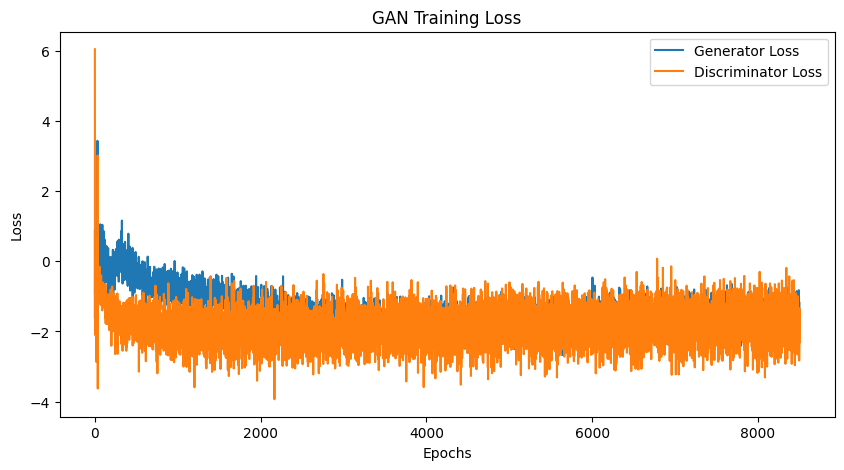

Epoch 9000, Loss D: -1.9035139083862305, Loss G: -1.4058881998062134


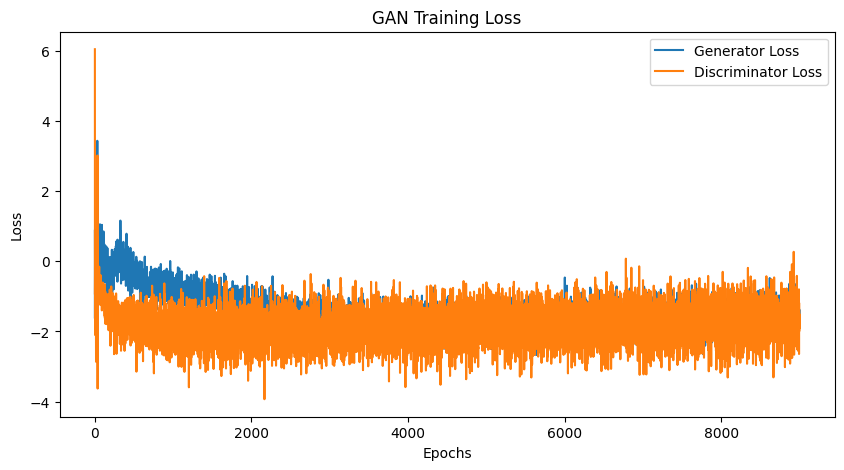

Epoch 9500, Loss D: -2.048076868057251, Loss G: -1.5049057006835938


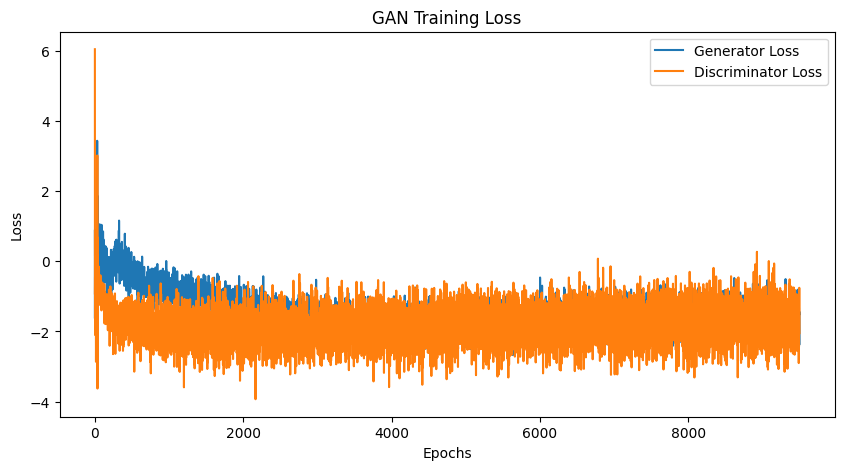

In [6]:
# --------------------
# 3️⃣ Training Loop (WGAN-GP)
# --------------------
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.9))

n_epochs = 10000
lambda_gp = 10
losses_G, losses_D = [], []

def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label='Generator Loss')
    plt.plot(losses_D, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Loss')
    plt.show()

for epoch in range(n_epochs):
    for real_samples in data_loader:
        real_samples = real_samples.float()
        batch_size = real_samples.size(0)
        
        # Train Discriminator
        optimizer_D.zero_grad()
        z = torch.randn(batch_size, 128)
        fake_samples = generator(z).detach()
        loss_D_real = -torch.mean(discriminator(real_samples))
        loss_D_fake = torch.mean(discriminator(fake_samples))
        gradient_penalty = compute_gradient_penalty(discriminator, real_samples, fake_samples)
        loss_D = loss_D_real + loss_D_fake + lambda_gp * gradient_penalty
        loss_D.backward()
        optimizer_D.step()
        
        # Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, 128)
        fake_samples = generator(z)
        loss_G = -torch.mean(discriminator(fake_samples))
        loss_G.backward()
        optimizer_G.step()
        
    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss D: {loss_D.item()}, Loss G: {loss_G.item()}")
        plot_losses()

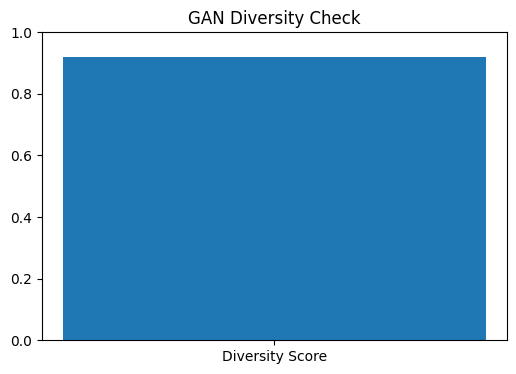

In [7]:
# --------------------
# 4️⃣ Diversity & Uniqueness Checks
# --------------------
def calculate_diversity(samples):
    unique_samples = set(tuple(sample) for sample in samples)
    return len(unique_samples) / len(samples) if len(samples) > 0 else 0  # Prevent zero division

def plot_diversity():
    z = torch.randn(1000, 128)
    generated_samples = generator(z).detach().numpy()
    diversity_score = calculate_diversity(generated_samples)

    plt.figure(figsize=(6, 4))
    plt.bar(['Diversity Score'], [diversity_score])
    plt.ylim(0, 1)
    plt.title('GAN Diversity Check')
    plt.show()

plot_diversity()

In [21]:
import pandas as pd
import torch

# --------------------
# ✅ Generate Final GAN Molecules (Save for Chemformer)
# --------------------
num_generated = 100  # Number of molecules to generate
latent_dim = 128  # Ensure this matches the GAN latent space

# Generate latent vectors
z_final = torch.randn(num_generated, latent_dim)

# Generate fake molecular fingerprints from GAN
final_fake_samples = generator(z_final).detach().numpy()

# Save generated latent vectors to CSV file
df_generated = pd.DataFrame(final_fake_samples)  
df_generated.to_csv("generated_molecules_vectors.csv", index=False)

print("✅ Generated molecular vectors saved to 'generated_molecules_vectors.csv'.")


✅ Generated molecular vectors saved to 'generated_molecules_vectors.csv'.
